In [13]:
import json
import os
import numpy as np

filename = os.getcwd().split('/')[:-1]
filename = '/'.join(filename) + '/dataset/sysid_data.json'

with open(filename, 'r') as f:
    data = json.load(f)

In [14]:
np.array(data['data'][0]['measured_states']).shape

(150, 32)

In [ ]:
import matplotlib.pyplot as plt

def plot_motor_responses(data, start, end):
    items = [item for idx, item in enumerate(data['data']) if start <= idx < end]
    fig, axes = plt.subplots(5, 2, figsize=(10, 12))

    for ax, item in zip(axes.flat, items):
        motor_idx = item['motor_idx']
        actions = np.array(item['actions_hw'])
        states = np.array(item['measured_states'])

        ax.plot(actions[:, motor_idx], label='action')
        ax.plot(states[:, motor_idx] / 0.32, label='measured')
        ax.set_title(f"{item['type']} motor {motor_idx}")
        ax.legend(fontsize=6)

    plt.tight_layout()
    plt.show()


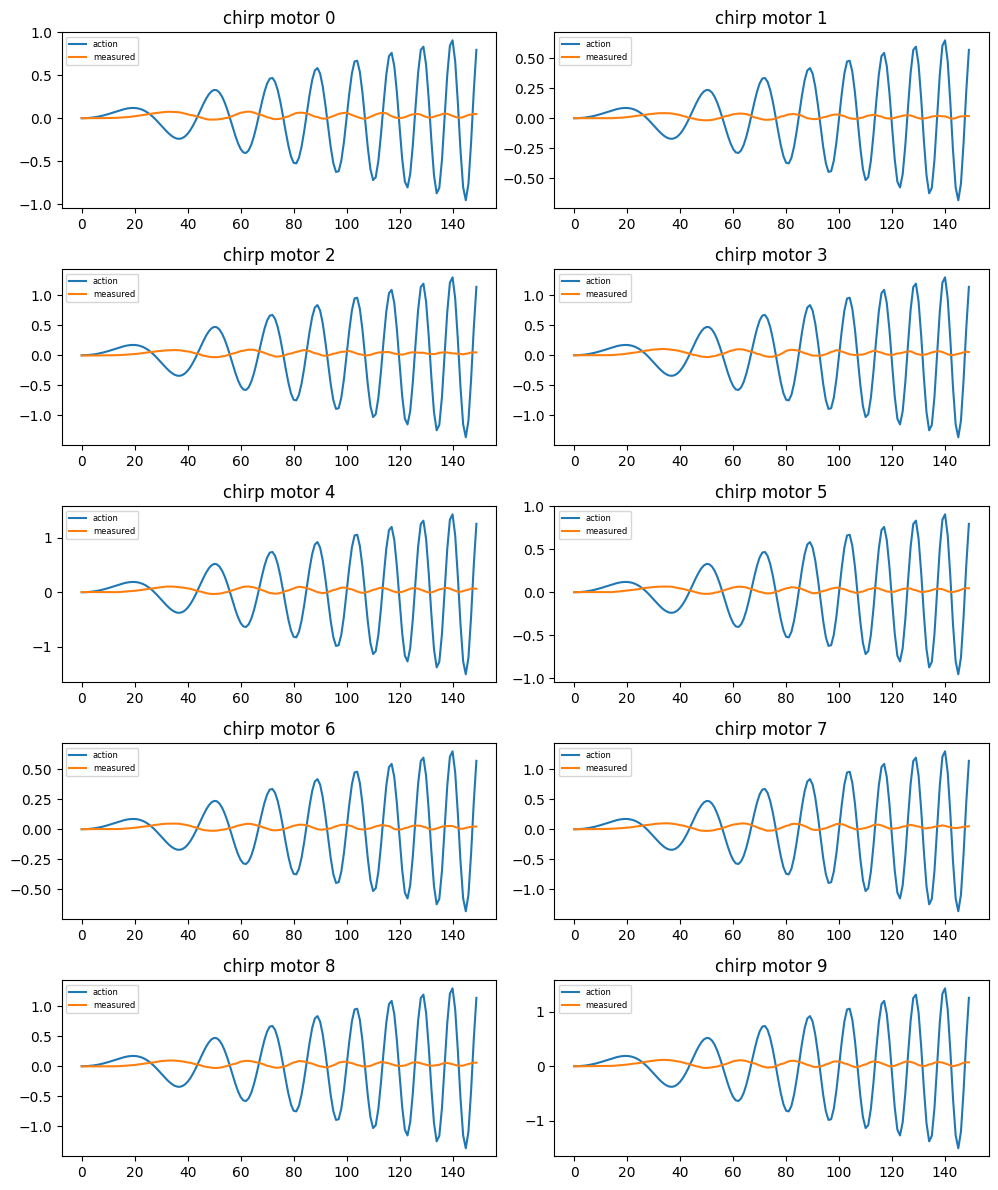

In [32]:
plot_motor_responses(data, 0, 10)


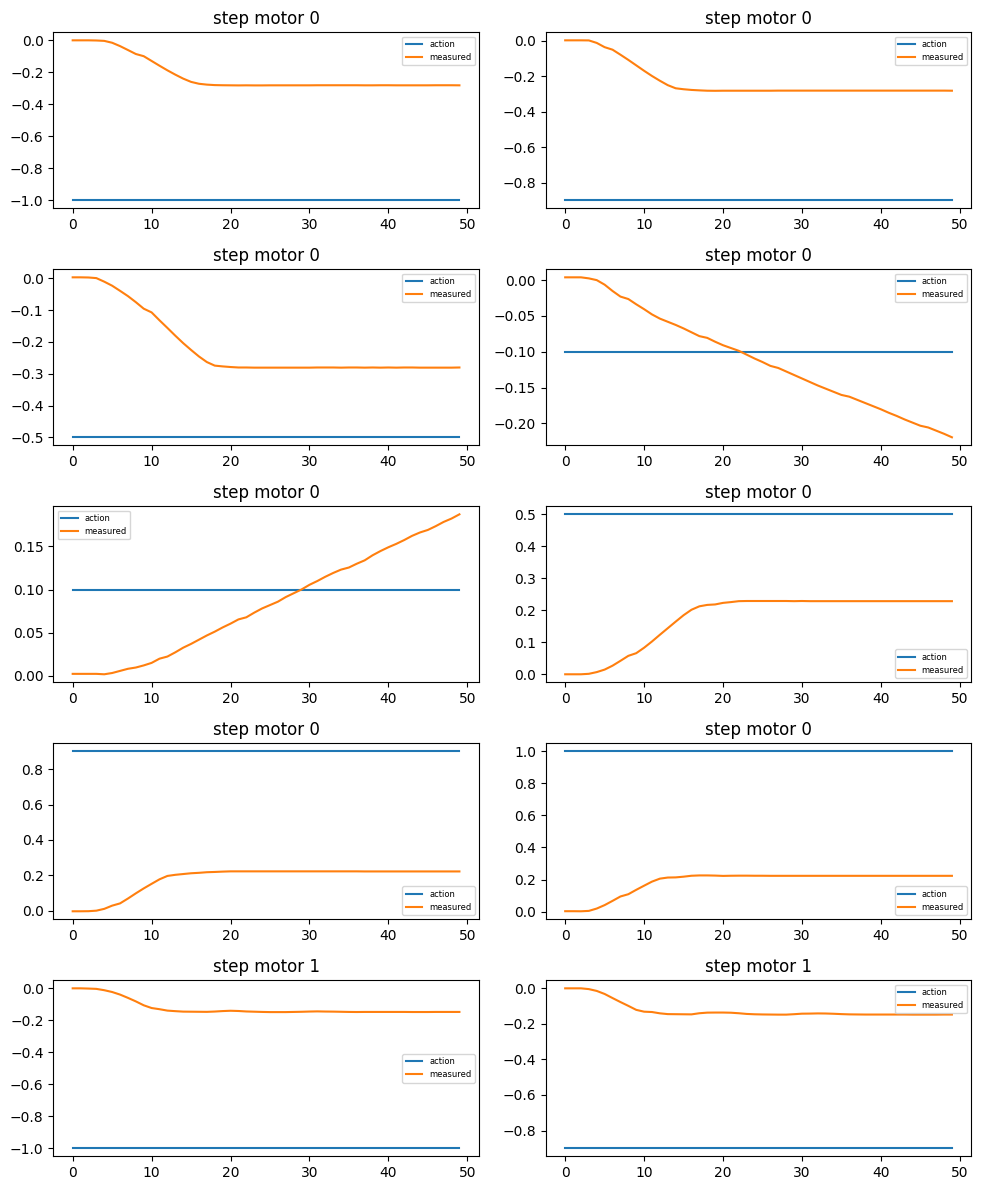

In [33]:
plot_motor_responses(data, 10, 20)


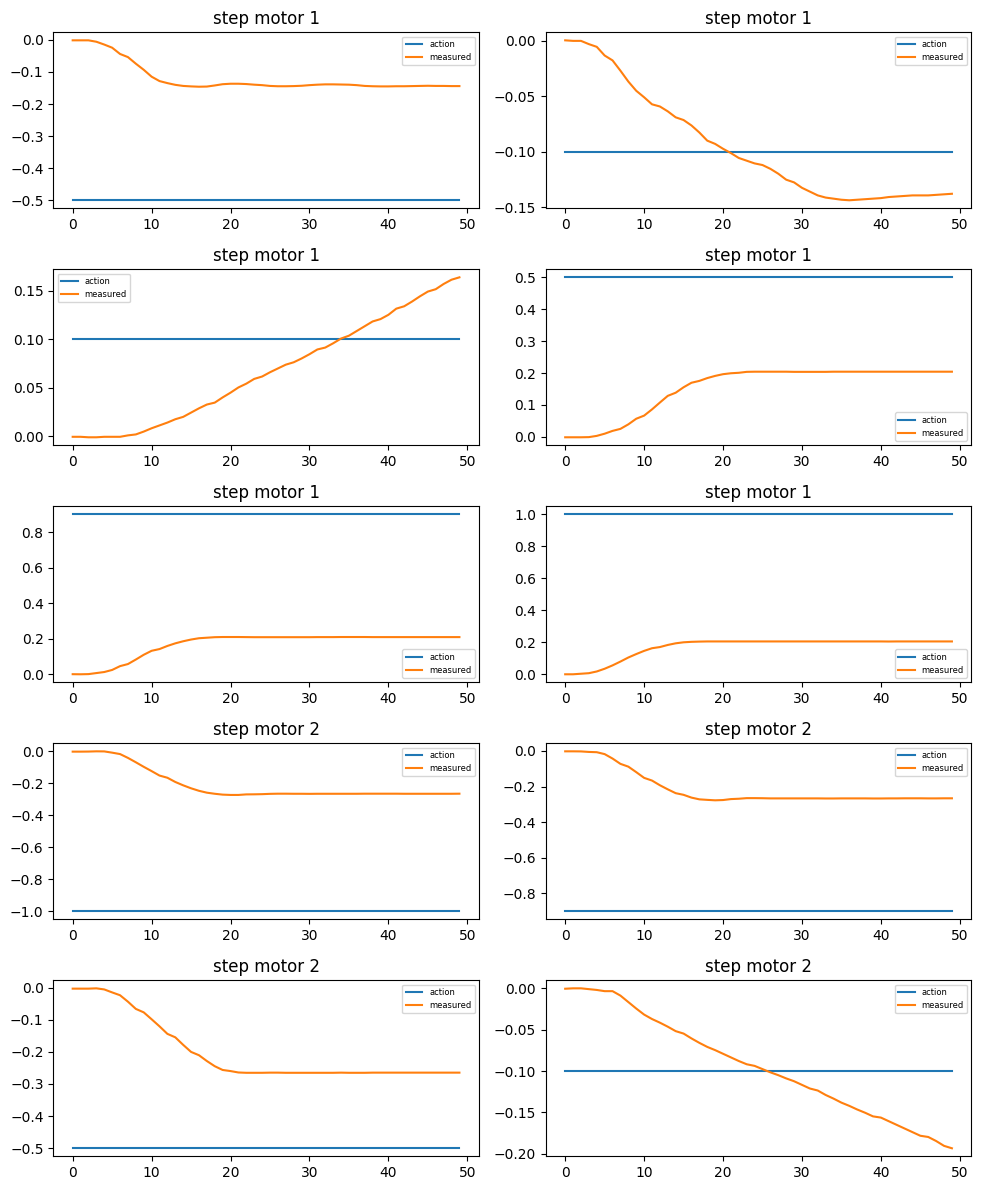

In [34]:
plot_motor_responses(data, 20, 30)

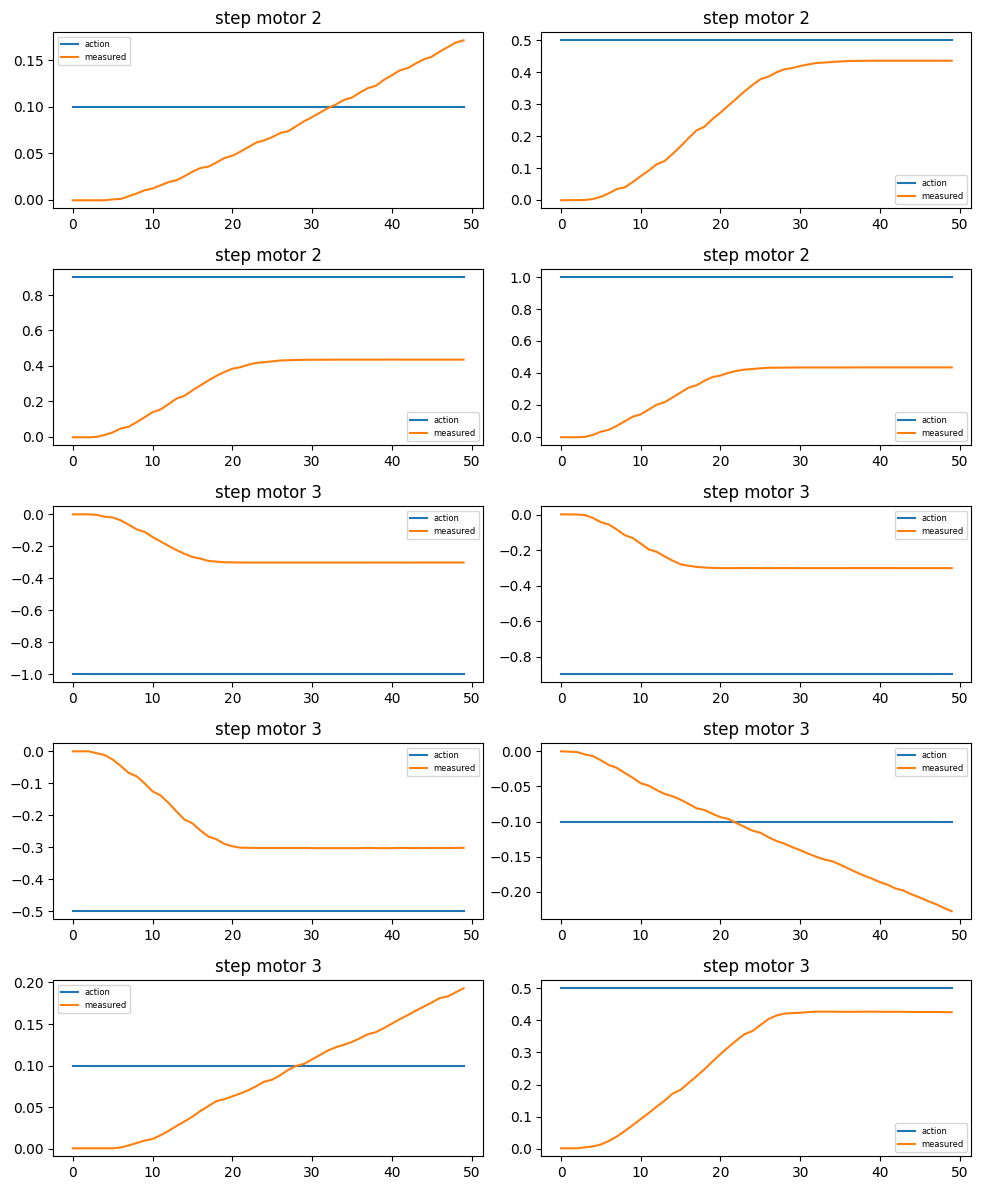

In [35]:
plot_motor_responses(data, 30, 40)

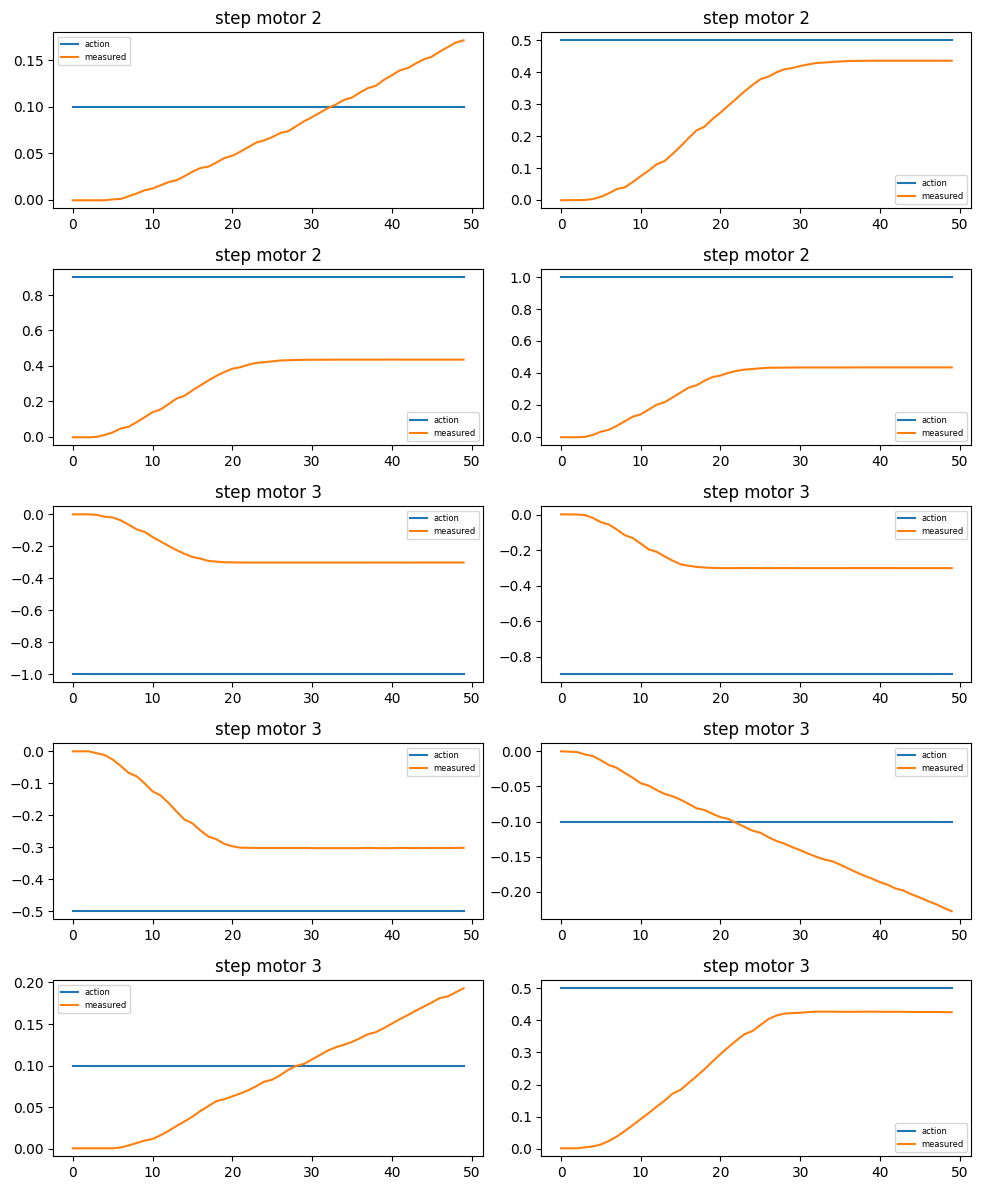

In [36]:
plot_motor_responses(data, 30, 40)

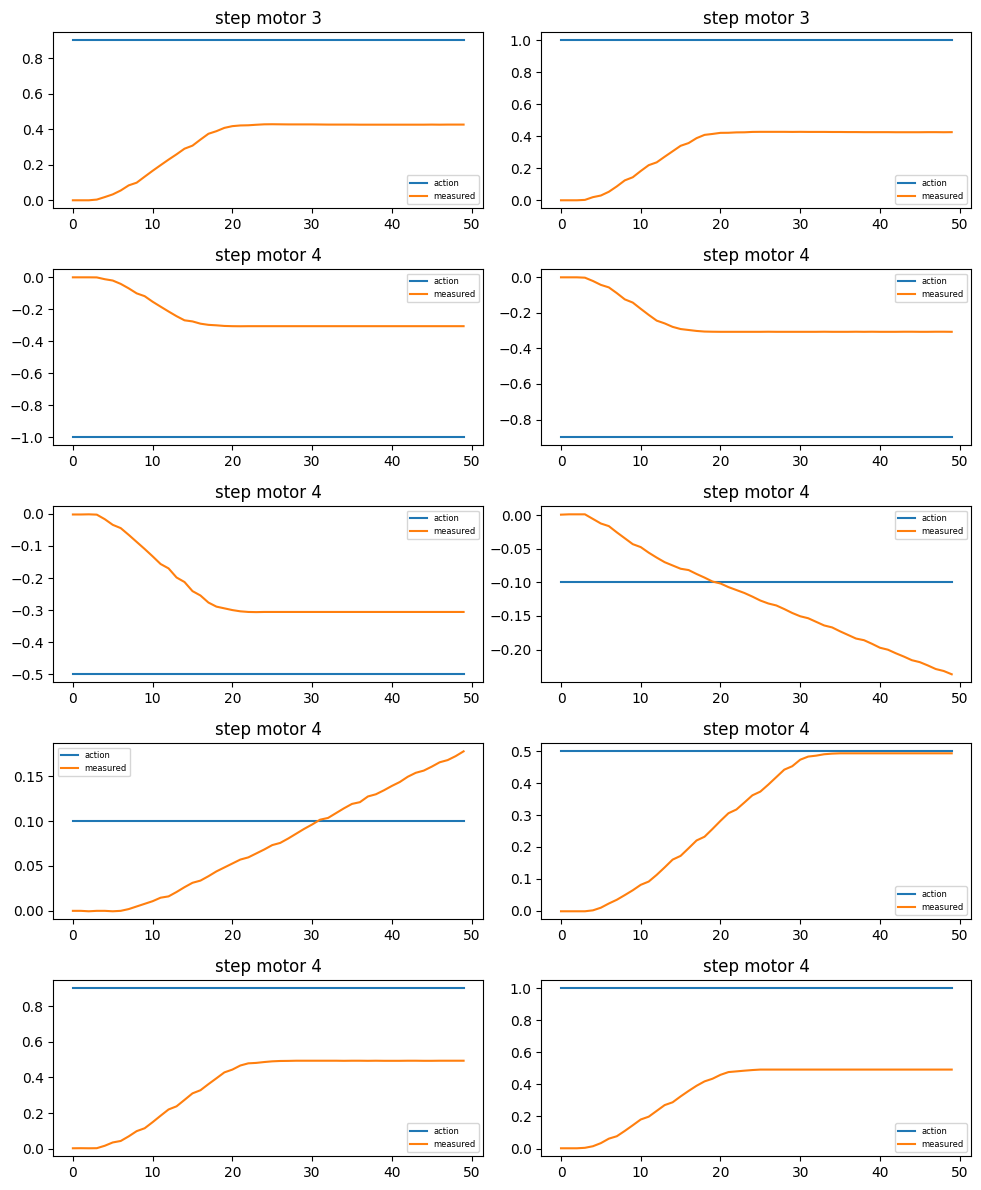

In [37]:
plot_motor_responses(data, 40, 50)

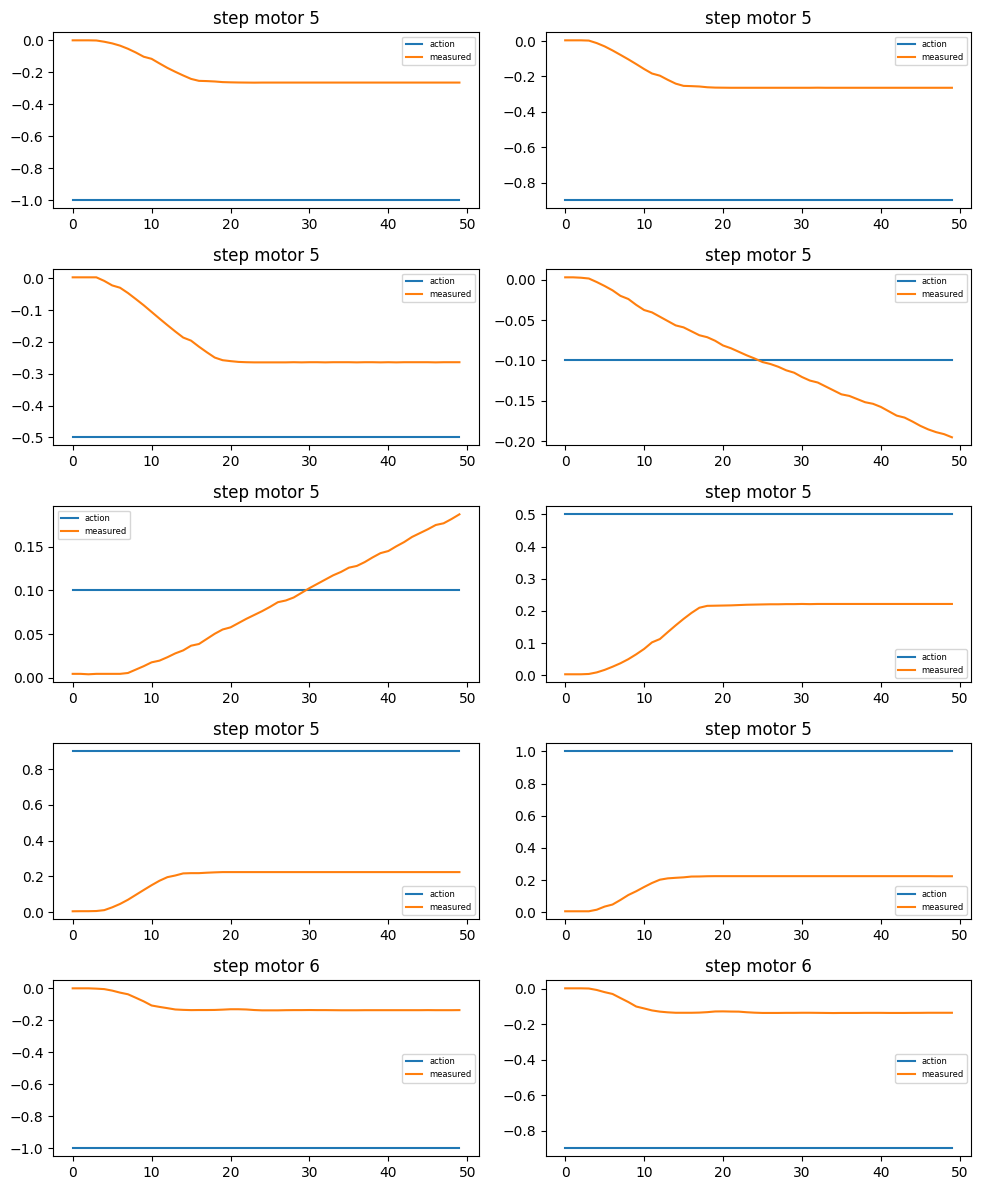

In [38]:
plot_motor_responses(data, 50, 60)

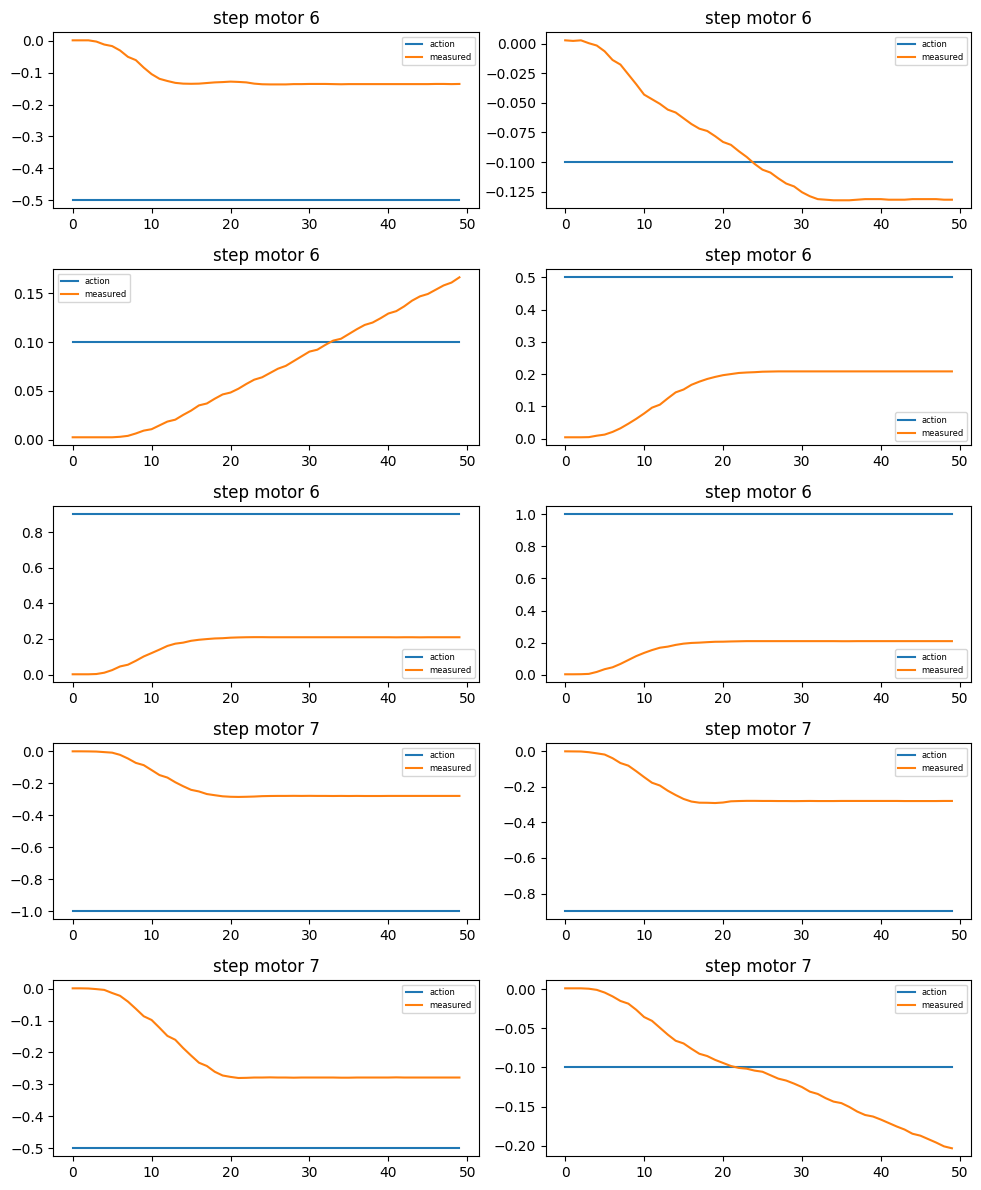

In [39]:
plot_motor_responses(data, 60, 70)

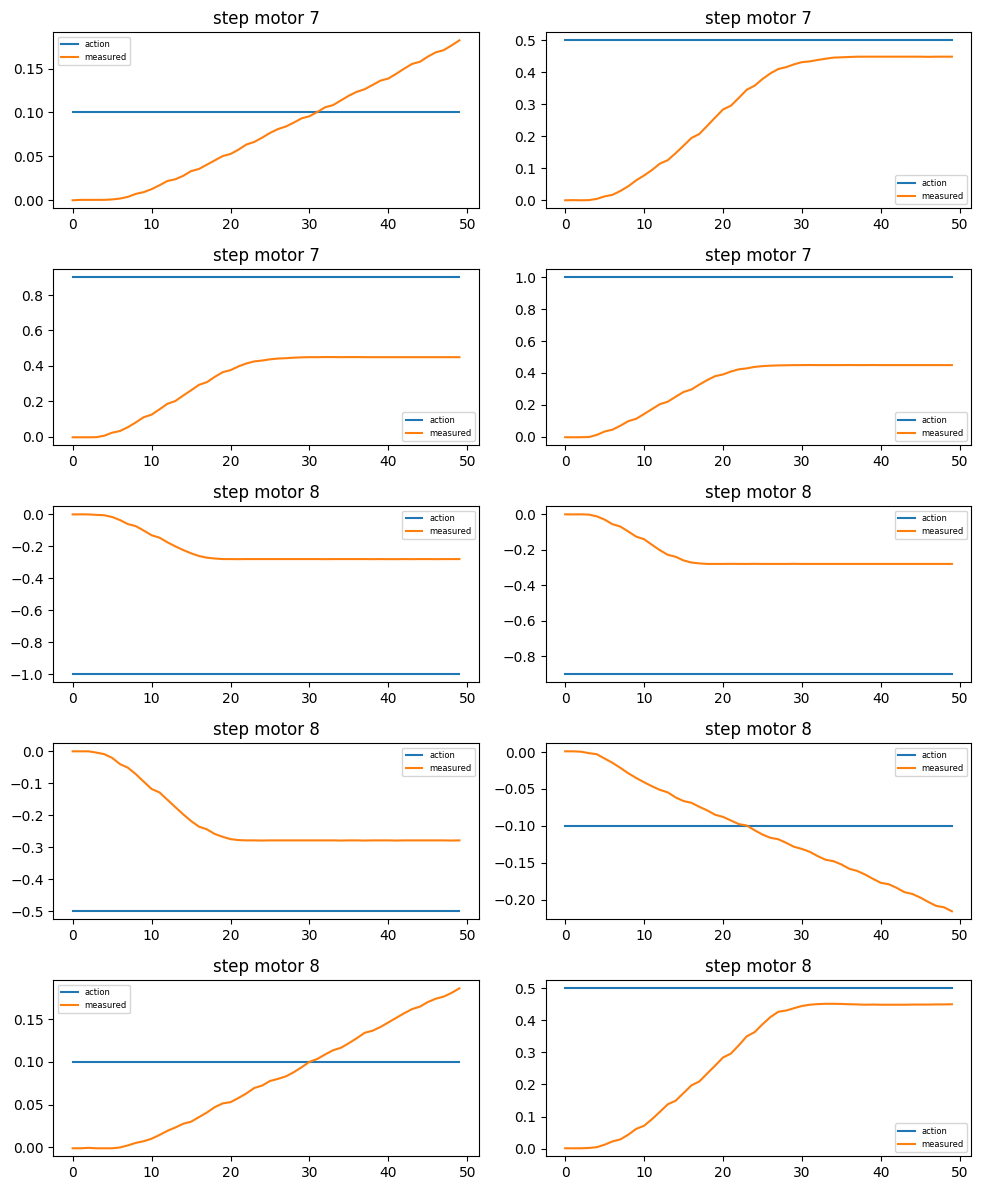

In [40]:
plot_motor_responses(data, 70, 80)

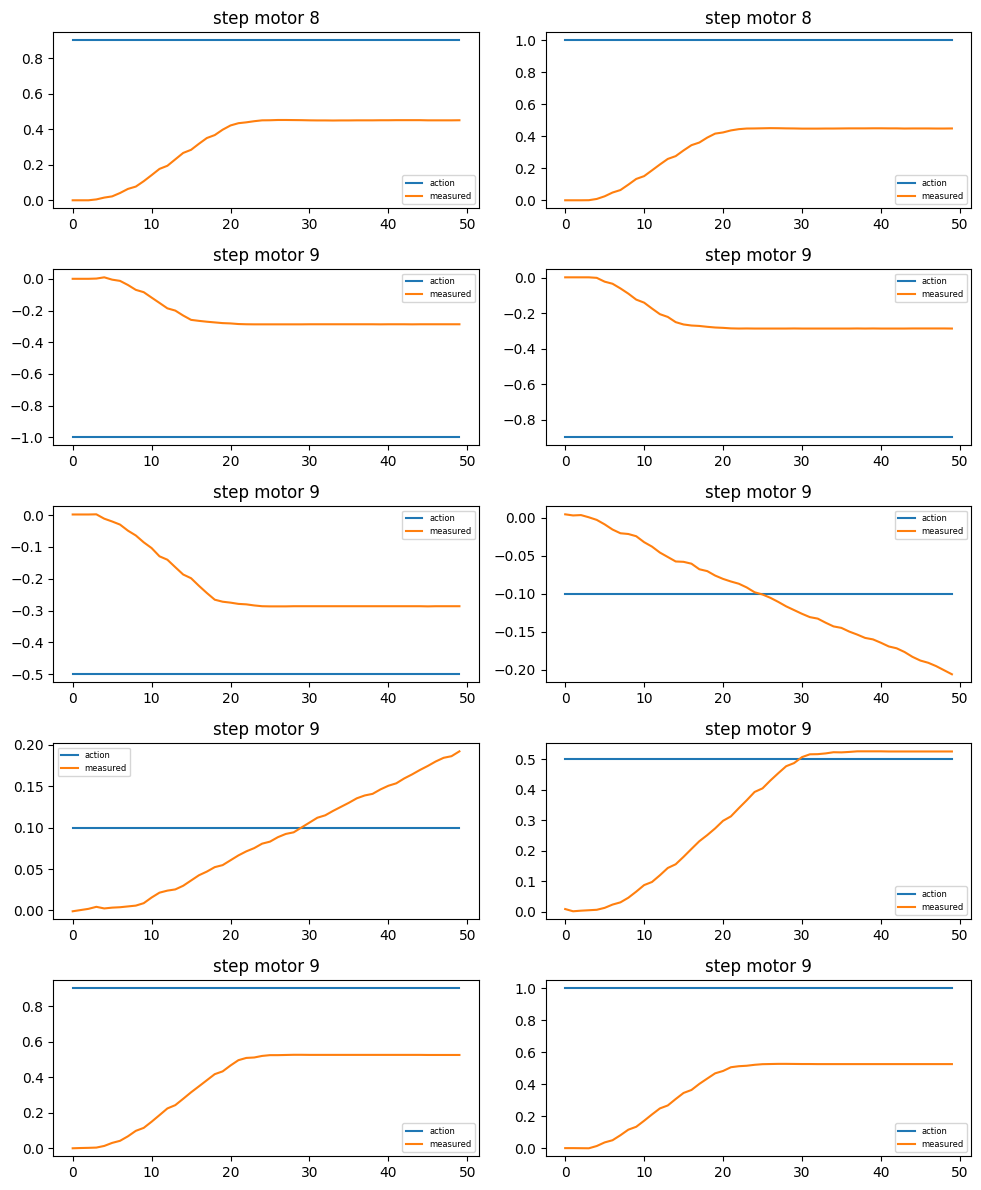

In [41]:
plot_motor_responses(data, 80, 90)

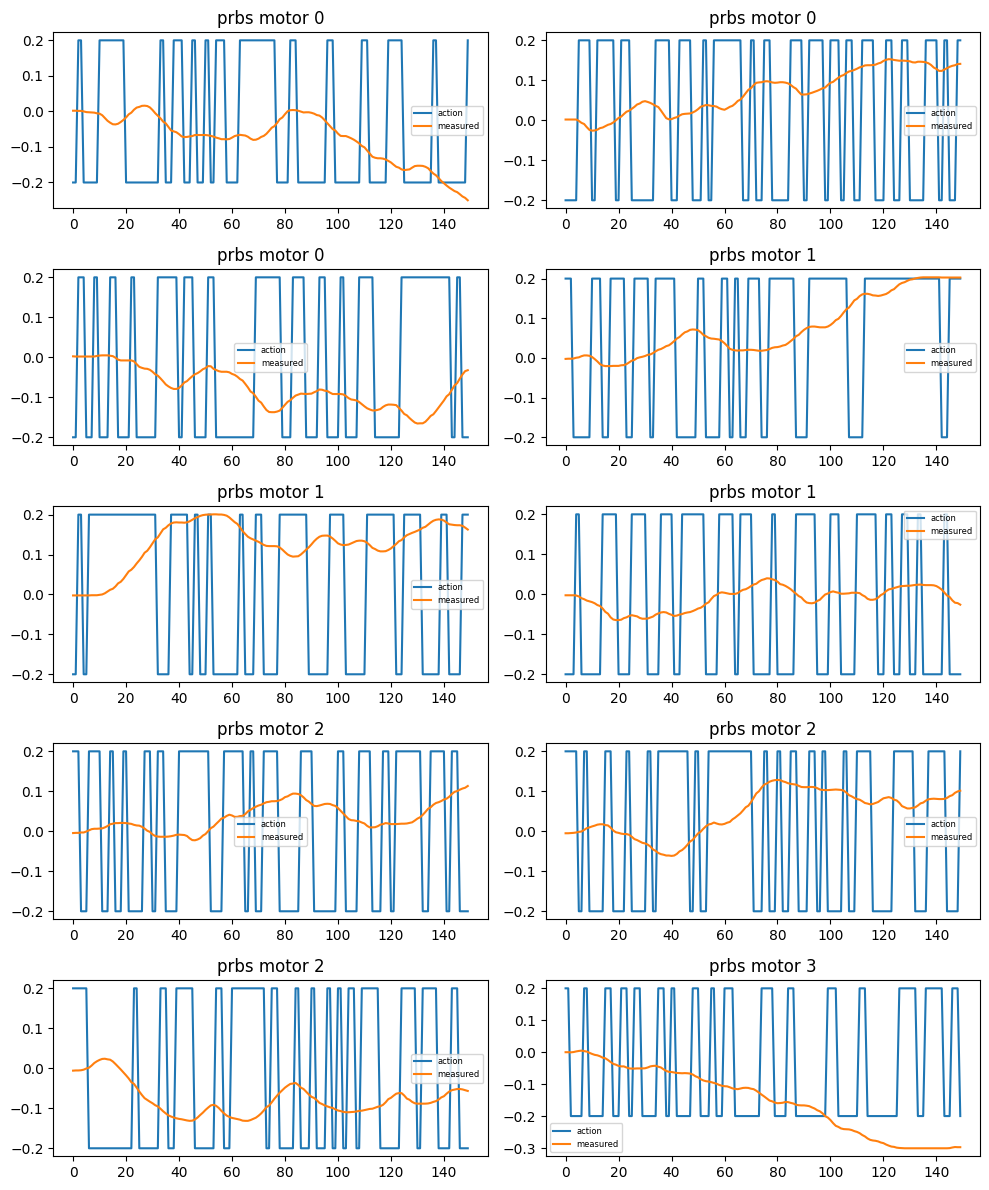

In [42]:
plot_motor_responses(data, 90, 100)

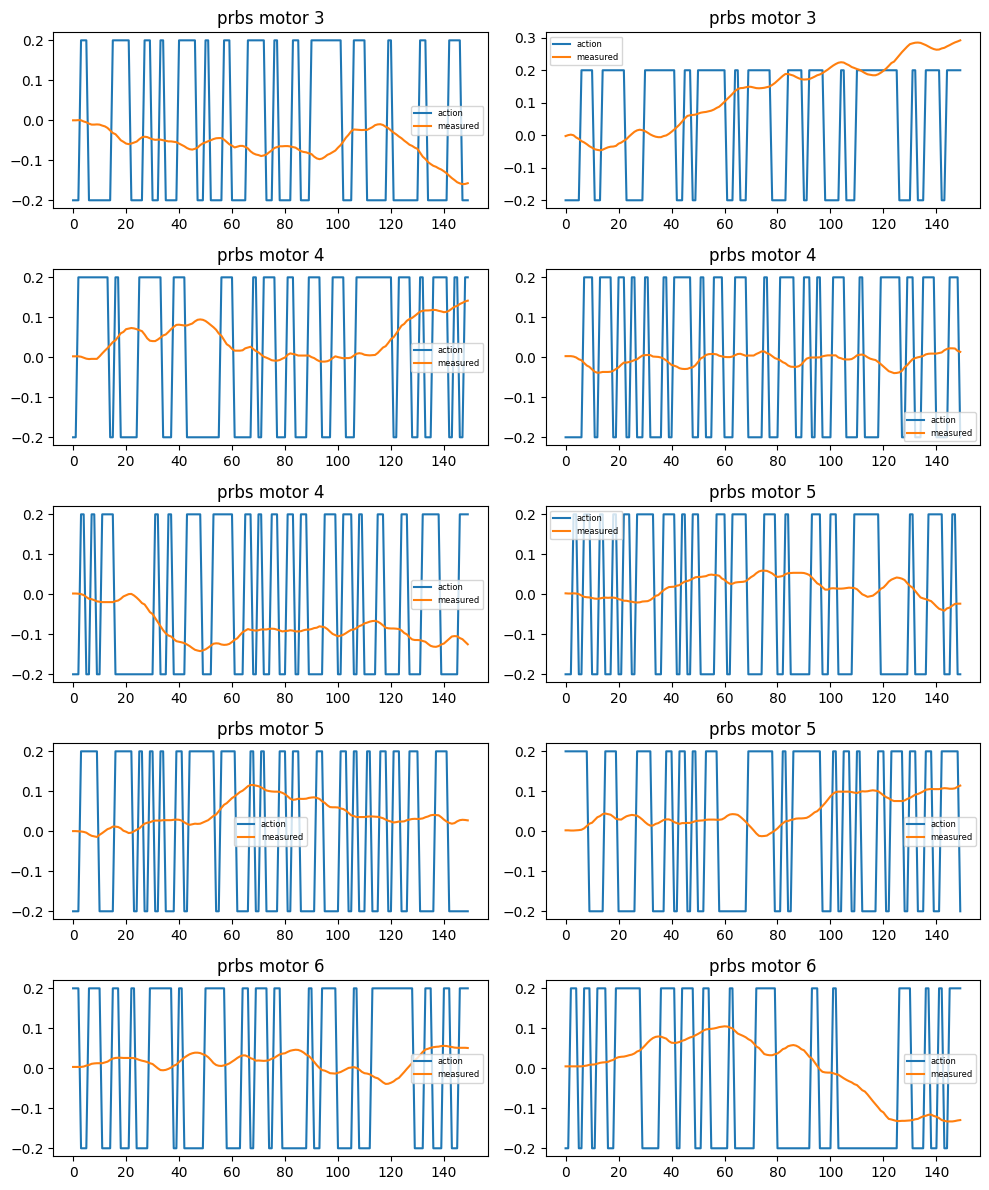

In [43]:
plot_motor_responses(data, 100, 110)

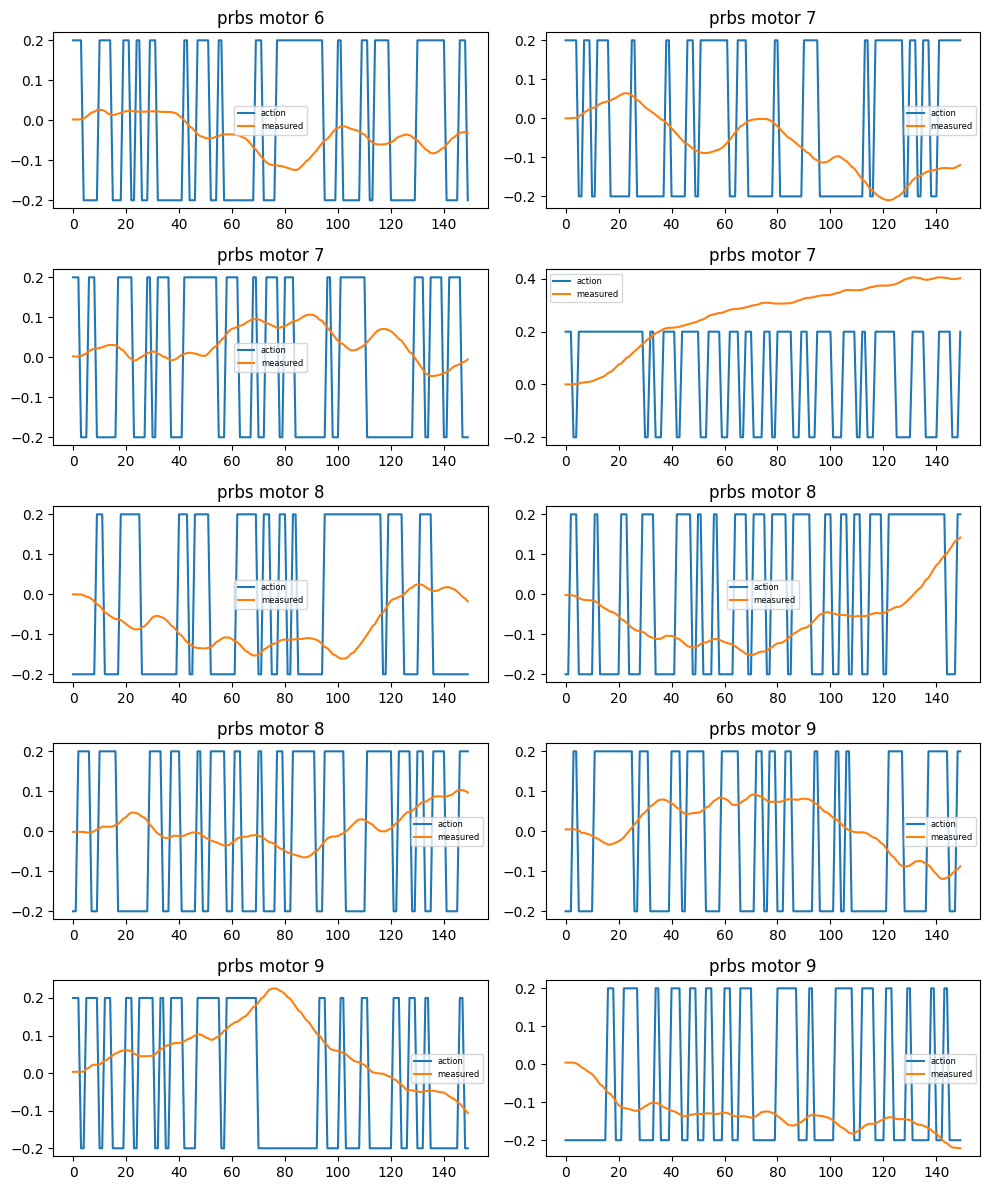

In [44]:
plot_motor_responses(data, 110, 120)

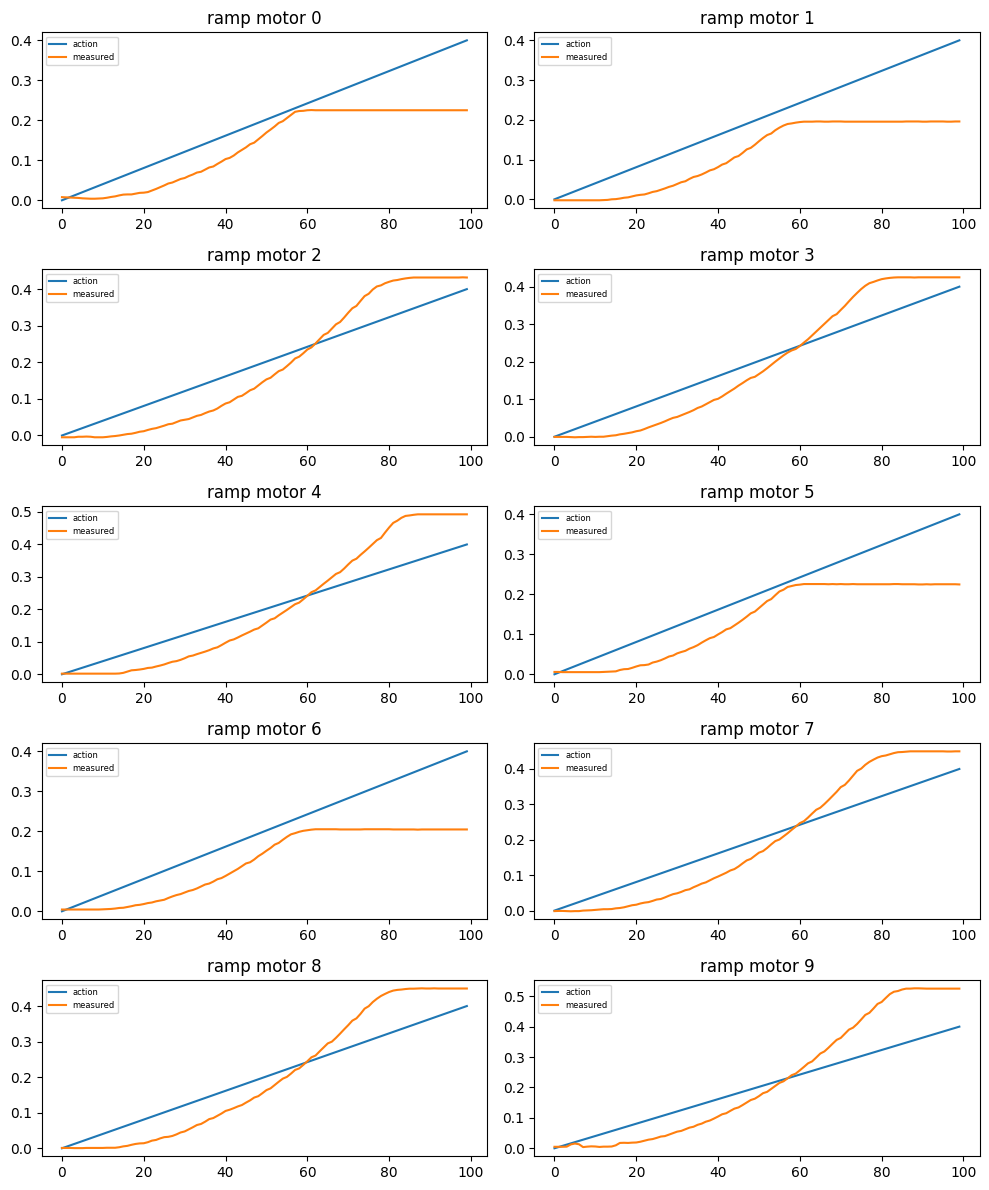

In [45]:
plot_motor_responses(data, 120, 130)

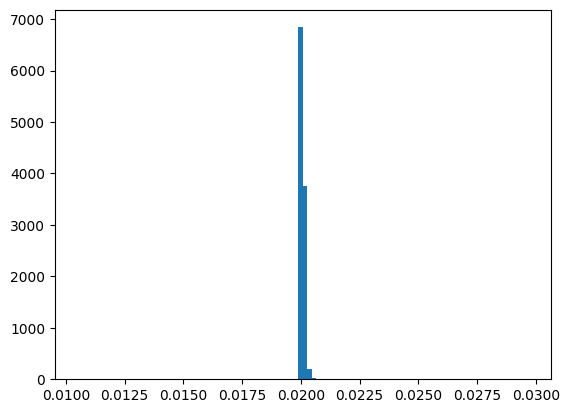

In [46]:
times = [item['times'] for idx, item in enumerate(data['data'])]
deltas = []
for t in times:
    t = np.array(t)
    d = t[1:] - t[:-1]
    deltas.extend(d)

deltas = np.array(deltas)
plt.hist(deltas, bins=100)
plt.show()

assert np.abs(deltas.mean() - 0.02) < 0.001, f"Delta mean is {deltas.mean()}"
